# Baseline forward solve: ultrasound over the Shepp-Logan phantom

For this run, we will use a source frequency of 300kHz. At a minimum wave speed of $1500 ms^{-1}$ (water background), the maximum wavelength we should observe is 

$$\lambda_\text{max} = \frac 1500 {3.0\times 10^6} = 0.005 m.$$

If we require say 6 points per wavelength then we require $dx = \frac {\lambda_\text{min}} {6} = 0.000833m$. Then for a domain of length $25cm$ we want $nx = 0.25/0.000833 = 300$. Let's set this up.

In [8]:
from odil_wave import Grid, SheppLoganModel, Sources, Wavefield, WaveEquation, Problem, ForwardLoss, GaussNewtonOptimiser

In [2]:
grid = Grid(nx=300, ny=300, xmax=0.25, ymax=0.25, c_ref=1800.0, cfl_safety=0.9)
print(grid.summary)

Nx, Ny, Nt: 300, 300, 666
dx, dy, dt: 0.000836m, 0.000836m, 0.000000s
CFL (at c = 1800.0):  0.899
x in [0.00, 0.25]m
y in [0.00, 0.25]m


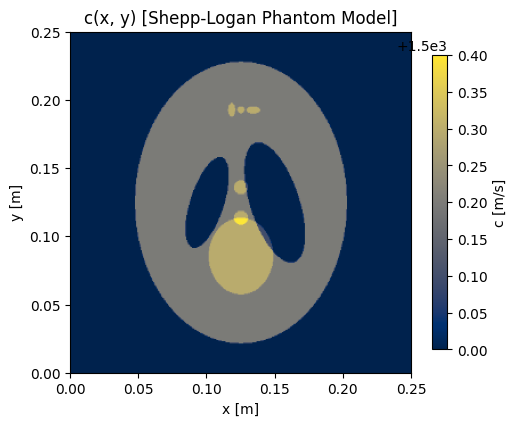

In [3]:
model = SheppLoganModel(grid, background_c=1500.0, interior_fill=0.9, mask_skull=True)
_ = model.show()

In [4]:
source = Sources(grid, n_sources=1, source_locs=((0.04, 0.125),), f0=300000)

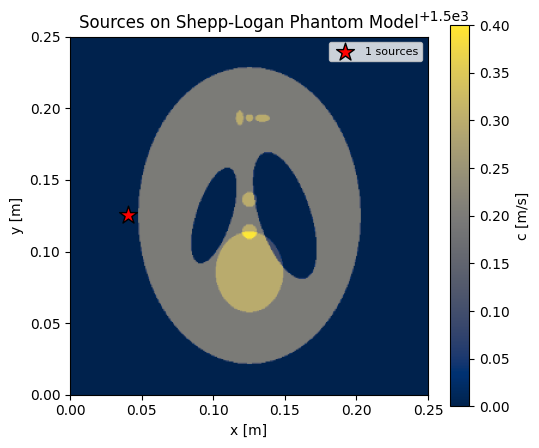

In [5]:
_ = source.show(model)

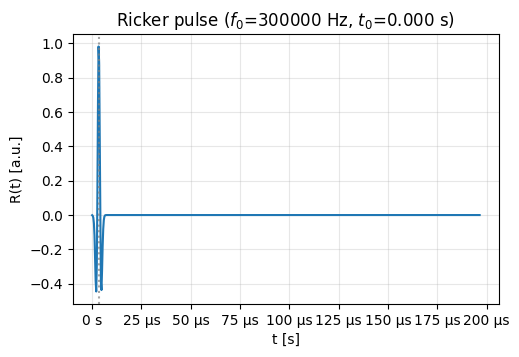

In [6]:
_ = source.plot_source_pulse()

In [7]:
wavefield = Wavefield(grid)

In [9]:
equation = WaveEquation(wavefield, model, time_order=2, space_order=8)

In [10]:
problem = Problem(equation, source)

In [11]:
loss = ForwardLoss(problem)

In [12]:
optimiser = GaussNewtonOptimiser(loss)

In [ ]:
result = optimiser.minimise(wavefield, method="paradiag", alpha=1e-3)

In [ ]:
result.exit_reason

In [ ]:
result.solution.animate(title="300kHz source over soft Shepp Logan Phantom")